# Activation Functions: The Friendly Guide

## What will we learn?

By the end of this notebook, you will understand:

- What an activation function is
- Why neural networks need activation functions
- How an activation function changes a number
- Linear, sigmoid, tanh, ReLU, Leaky ReLU, PReLU, and Swish
- The formula, example, graph idea, and limitation of each function
- Which activation function is usually used in different layers of a neural network

Do not worry if the words *neural network* sound scary. A neural network is just a collection of small mathematical decision-makers. It is not a brain in a jar, and it will not ask you for your homework.

---

# 1. What is an activation function?

An **activation function** is a rule that decides how strongly a neuron should respond to its input.

Imagine a neuron as a tiny gatekeeper:

1. It receives numbers.
2. It combines those numbers.
3. The activation function decides what number should continue to the next layer.

A neuron first calculates a weighted sum:

$$
z = w_1x_1 + w_2x_2 + b
$$

Then it applies an activation function:

$$
a = f(z)
$$

Here:

- $x_1, x_2$ are input values.
- $w_1, w_2$ are weights, which tell us how important the inputs are.
- $b$ is the bias, which gives the neuron a small adjustment.
- $z$ is the value before activation.
- $f$ is the activation function.
- $a$ is the value sent to the next layer.

In plain language: the neuron does some arithmetic, and the activation function says, â€œHow much of this result should we pass forward?â€

## Why do we need activation functions?

Without activation functions, every layer would perform only a linear calculation. Even if we stacked 100 linear layers, the whole network would still behave like one large linear equation. That is a lot of furniture for one very small room.

Activation functions add **non-linearity**. Non-linearity allows a neural network to learn complicated patterns such as:

- Recognizing a cat in a picture
- Deciding whether an email is spam
- Predicting house prices
- Understanding whether a patient may have a disease

---

# 2. A tiny example problem

Suppose a neuron receives two inputs:

- $x_1 = 2$, with weight $w_1 = 3$
- $x_2 = 1$, with weight $w_2 = 4$
- Bias $b = -2$

First calculate the weighted sum:

$$
z = (3)(2) + (4)(1) - 2 = 8
$$

Now choose an activation function.

- With a linear function, the output is $8$.
- With ReLU, the output is also $8$ because $8$ is positive.
- With sigmoid, the output is approximately $0.9997$.
- With tanh, the output is almost $1$.

The same input can therefore produce very different outputs depending on the function. The activation function is the neuronâ€™s personality. Some are calm, some are dramatic, and some simply turn negative numbers off.

---

# 3. Linear Activation Function

## Definition

A linear activation function returns a value that changes in a straight-line manner.

## Formula

$$
f(x) = x$$

A more general version is:

$$
f(x) = mx + c$$

where $m$ controls the slope and $c$ controls the starting point.

## Example

If $f(x) = 2x + 1$ and $x = 3$:

$$
f(3) = 2(3) + 1 = 7
$$

For the simple version $f(x)=x$, if $x=-5$, the output is $-5$.

## Graph

The graph is a straight line. For $f(x)=x$, it passes through the origin $(0,0)$ and rises one unit for every one unit moved to the right.

## Limitation

A linear function cannot learn complex curved patterns because it has no non-linearity. It is useful, but asking it to solve every deep-learning problem is like asking a ruler to draw a circle. Very confident. Completely unhelpful.

## Common use

A linear activation is commonly used in the output layer for **regression**, where the answer can be any real number, such as:

- Price of a house
- Temperature
- Salary
- Amount of rainfall

---

# 4. Sigmoid Activation Function

## Definition

The sigmoid function squeezes any number into a value between $0$ and $1$.

This makes it useful for probabilities. A result near $0$ means â€œprobably no,â€ and a result near $1$ means â€œprobably yes.â€

## Formula

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}$$

The number $e$ is a mathematical constant. You do not need to chase it around the room; it is approximately $2.718$.

## Example

For $x=0$:

$$
sigmoid(0) = \frac{1}{1+e^0} = \frac{1}{2}=0.5$$

For a large positive number, the output gets close to $1$. For a large negative number, the output gets close to $0$.

## Graph

The sigmoid graph has an S shape:

- It stays close to $0$ on the far left.
- It rises around $0$.
- It stays close to $1$ on the far right.

## Limitation: vanishing gradient problem

At the far left and far right, the sigmoid graph becomes almost flat. Its gradient, or slope, becomes very small.

During learning, the network uses gradients to update its weights. If the gradient is almost zero, the weights barely change. Learning then becomes painfully slow. The network is technically working, in the same way a snail technically travels.

Sigmoid outputs are also not centered around zero, which can make optimization less efficient in hidden layers.

## Common use

Sigmoid is often used in the output layer for **binary classification**, such as:

- Spam or not spam
- Sick or healthy
- Pass or fail

---

# 5. tanh Activation Function

## Definition

The tanh, or hyperbolic tangent, function converts any number into a value between $-1$ and $1$.

## Formula

$$
tanh(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

## Example

$$
tanh(0)=0$$

For a large positive input, tanh approaches $1$. For a large negative input, it approaches $-1$.

For example:

$$
tanh(1) \approx 0.762$$

## Graph

The tanh graph is also S-shaped, but it is centered around zero:

- Far left: close to $-1$
- At zero: exactly $0$
- Far right: close to $1$

## Limitation: vanishing gradient problem

Like sigmoid, tanh becomes nearly flat for very large positive or negative inputs. Its gradient becomes tiny, so earlier layers may learn very slowly.

Tanh is centered around zero, which is better than sigmoid, but it still has the flat-gradient problem. Improvement is nice; perfection was apparently busy.

## Common use

Tanh can be used in hidden layers and is historically common in recurrent neural networks. In many modern deep networks, ReLU-family functions are preferred for hidden layers.

---

# 6. ReLU Activation Function

ReLU means **Rectified Linear Unit**.

## Definition

ReLU keeps positive values and changes negative values to zero.

## Formula

$$
ReLU(x) = max(0,x)
$$

## Example

- $ReLU(5)=5$
- $ReLU(0)=0$
- $ReLU(-3)=0$

## Graph

The graph looks like a bent line:

- For negative inputs, it lies flat on the x-axis.
- For positive inputs, it rises like the line $y=x$.

## Limitation: dying ReLU problem

If a neuron repeatedly receives negative values, ReLU always outputs zero. Its gradient is also zero there, so the neuron may stop learning permanently.

Such a neuron is called a **dead neuron**. It is not sleeping. It has simply stopped contributing to the group project.

## Advantages

- Very simple and fast to calculate
- Usually avoids the severe saturation problem of sigmoid and tanh for positive values
- Works well in many hidden layers

## Common use

ReLU is a popular default for hidden layers in many neural networks.

---

# 7. Leaky ReLU Activation Function

## Definition

Leaky ReLU is a modified ReLU that allows a small negative value instead of sending every negative input to exactly zero.

## Formula

$$
LeakyReLU(x) =
\begin{cases}
 x, & x > 0 \\
 \alpha x, & x \leq 0
\end{cases}
$$

Usually, $\alpha$ is a small number such as $0.01$.

## Example

Using $\alpha=0.01$:

- $LeakyReLU(5)=5$
- $LeakyReLU(-3)=0.01(-3)=-0.03$

## Graph

For positive values, the graph rises like ReLU. For negative values, it has a small downward slope instead of becoming completely flat.

## Limitation

The slope $\alpha$ must be chosen. If it is too small, the function behaves almost like ordinary ReLU. If it is too large, the negative side may pass too much information.

The function reduces the dying ReLU problem, but it does not magically make every model accurate. Sadly, no activation function comes with a â€œsolve everythingâ€ button.

## Common use

Leaky ReLU is often used in hidden layers when ordinary ReLU causes too many dead neurons.

---

# 8. PReLU Activation Function

PReLU means **Parametric ReLU**.

## Definition

PReLU is similar to Leaky ReLU, but the negative slope $\alpha$ is learned by the neural network instead of being fixed by us.

## Formula

$$
PReLU(x) =
\begin{cases}
 x, & x > 0 \\
 \alpha x, & x \leq 0
\end{cases}
$$

The formula looks like Leaky ReLU because the important difference is that $\alpha$ is trainable.

## Example

Suppose the network has learned $\alpha=0.2$:

$$
PReLU(-3) = 0.2(-3)=-0.6
$$

If training later learns $\alpha=0.05$, the same negative input would produce:

$$
PReLU(-3)=0.05(-3)=-0.15
$$

## Graph

The positive side is the same as ReLU. The negative side is a sloping line, and its slope can change during training.

## Limitation

PReLU adds extra trainable parameters. This can improve flexibility, but it can also increase the risk of overfitting, especially with small datasets.

It is flexible, but flexibility is not free. Even mathematics sends an invoice.

## Common use

PReLU can be used in hidden layers when we want the model to learn how much negative information should pass through.

---

# 9. SWISH Activation Function

## Definition

Swish is a smooth activation function that multiplies the input by its sigmoid value.

## Formula

$$
Swish(x) = x \cdot sigmoid(x)
$$

or:

$$
Swish(x)=\frac{x}{1+e^{-x}}
$$

## Example

For $x=2$:

$$
sigmoid(2) \approx 0.881
$$

Therefore:

$$
Swish(2) = 2(0.881) \approx 1.762
$$

For $x=0$, Swish returns $0$. For negative values, it allows some information to pass instead of cutting everything off sharply.

## Graph

The Swish graph is smooth:

- It rises for positive values.
- It does not have the sharp corner found in ReLU.
- It allows small negative outputs.

## Limitation

Swish is more complicated to calculate than ReLU because it uses the sigmoid function. It may improve performance in some networks, but it is not always better enough to justify the extra computation.

Also, â€œnewerâ€ does not automatically mean â€œbest.â€ That is true for activation functions and also for most phone launches.

## Common use

Swish can be used in hidden layers, especially in deeper models where smooth behavior may help learning.

---

# 10. Quick comparison

| Function | Output range | Main strength | Main limitation |
|---|---:|---|---|
| Linear | Any value | Good for regression output | Cannot learn complex patterns alone |
| Sigmoid | $0$ to $1$ | Useful for binary probabilities | Vanishing gradients |
| tanh | $-1$ to $1$ | Zero-centered output | Vanishing gradients |
| ReLU | $0$ to infinity | Fast and effective | Dying ReLU |
| Leaky ReLU | Any value, usually small negatives | Keeps a negative slope | Slope must be selected |
| PReLU | Any value, usually small negatives | Learns the negative slope | Adds trainable parameters |
| Swish | Usually slightly below zero to infinity | Smooth and flexible | More computation |

---

# 11. Which activation function should we use?

## Hidden layers

For hidden layers, common choices are:

- ReLU: the usual simple starting point
- Leaky ReLU: useful when many ReLU neurons die
- PReLU: useful when the model should learn the negative slope
- Swish: useful when a smooth function works better for the model
- tanh: still useful in some sequence and recurrent models

## Output layer

The output activation depends on the type of problem:

### Regression

Use a **linear** activation when the output can be any real number.

Example: predicting a house price.

### Binary classification

Use **sigmoid** when there are two possible classes.

Example: predicting whether an email is spam.

### Multi-class classification

Use **softmax** when exactly one class should be selected from several classes.

Example: deciding whether an image shows a cat, dog, or bird.

Softmax is not listed as one of the main functions in this notebook, but it is important for output layers. It converts several scores into probabilities whose total is $1$.

### Multi-label classification

Use separate **sigmoid** outputs when several labels can be true at the same time.

Example: an image can contain both a person and a bicycle.

---

# 12. A simple layer-by-layer example

Imagine a network that predicts whether a picture contains a dog.

1. **Input layer:** receives the pixel values.
2. **Hidden layer 1:** uses ReLU to find simple patterns such as edges.
3. **Hidden layer 2:** uses ReLU, Leaky ReLU, PReLU, or Swish to combine patterns such as ears and eyes.
4. **Output layer:** uses sigmoid to produce a probability.

If the output is $0.92$, we can say the model estimates a $92\%$ probability that the picture contains a dog.

The model is not â€œseeingâ€ like a person. It is processing numbers very quickly and pretending that this counts as intuition. In fairness, it often works.

---

# 13. Graphs of the activation functions

The next code cell draws the functions so you can see their shapes. Seeing the graphs makes the differences much easier to remember:

- Linear: straight line
- Sigmoid: S shape between $0$ and $1$
- tanh: S shape between $-1$ and $1$
- ReLU: flat on the left and rising on the right
- Leaky ReLU and PReLU: small slope on the negative side
- Swish: smooth curve

---

# 14. Final summary

An activation function controls the output of a neuron and adds non-linearity to a neural network.

Remember these simple ideas:

- **Linear** passes values through in a straight-line way.
- **Sigmoid** gives a number between $0$ and $1$, like a probability.
- **tanh** gives a number between $-1$ and $1$.
- **ReLU** keeps positive values and removes negative values.
- **Leaky ReLU** lets a small amount of negative information pass.
- **PReLU** learns how much negative information should pass.
- **Swish** smoothly combines the input with its sigmoid value.

There is no single best activation function for every problem. The right choice depends on the layer, the task, the data, and how the model learns.

The practical rule is simple: start with a sensible choice, test it, and look at the results. Neural networks are powerful, but they still appreciate evidence.

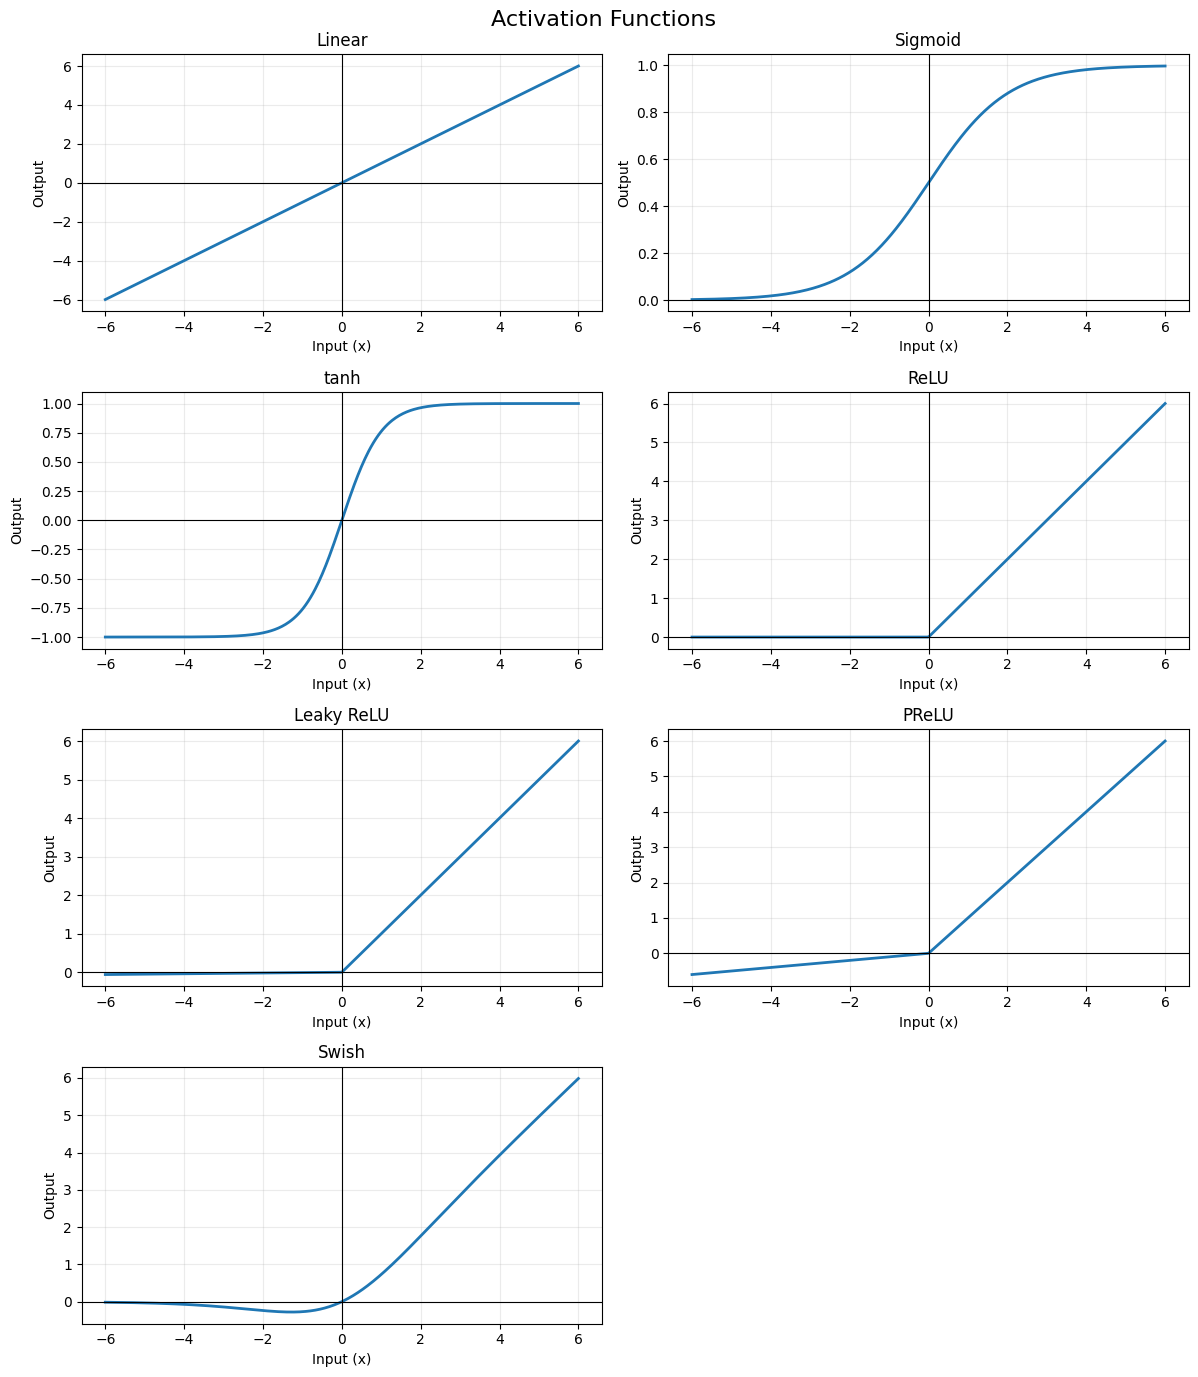

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)

linear = x
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.01 * x)
prelu = np.where(x > 0, x, 0.1 * x)
swish = x * sigmoid

functions = {
    "Linear": linear,
    "Sigmoid": sigmoid,
    "tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu,
    "PReLU": prelu,
    "Swish": swish,
}

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()

for axis, (name, values) in zip(axes, functions.items()):
    axis.plot(x, values, linewidth=2)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(name)
    axis.set_xlabel("Input (x)")
    axis.set_ylabel("Output")
    axis.grid(alpha=0.25)

axes[-1].axis("off")
fig.suptitle("Activation Functions", fontsize=16)
fig.tight_layout()
plt.show()